<a href="https://colab.research.google.com/github/Mehtabul-Islam/CSE422---artificial-intelligence/blob/main/LAB%2003/Assignment_3_Solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CSE422 Lab 03: Adversarial Search
Md. Mehtabul Islam | 24301400

# Assignment 3


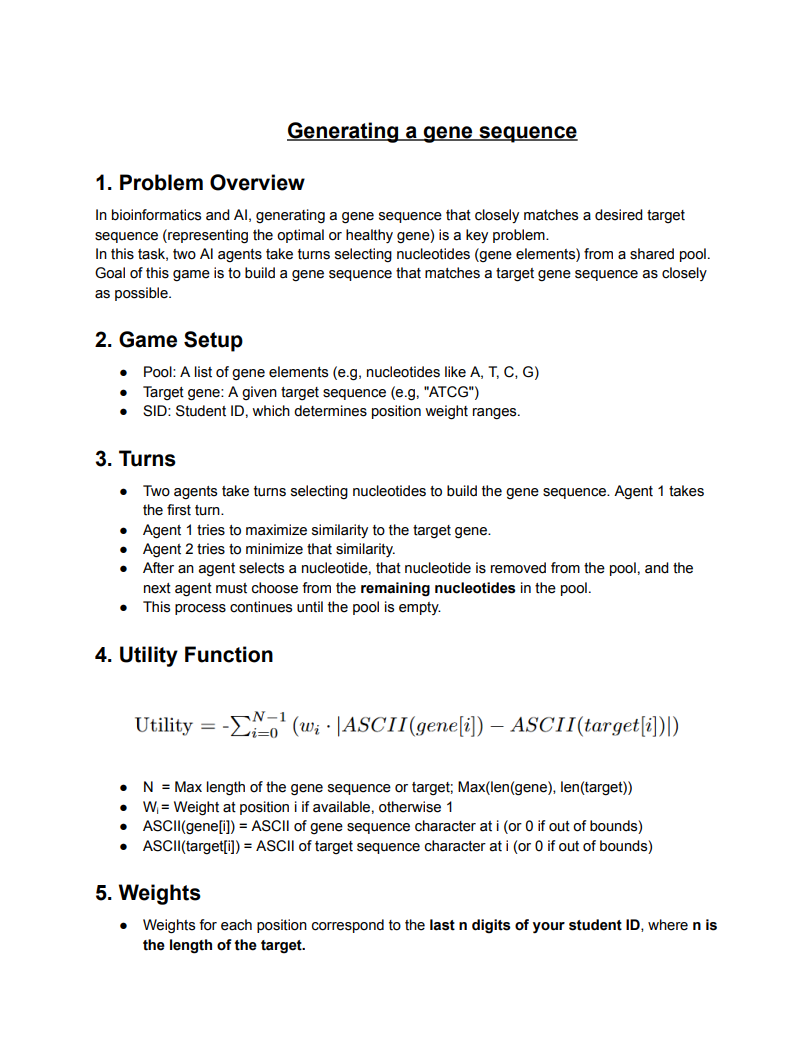

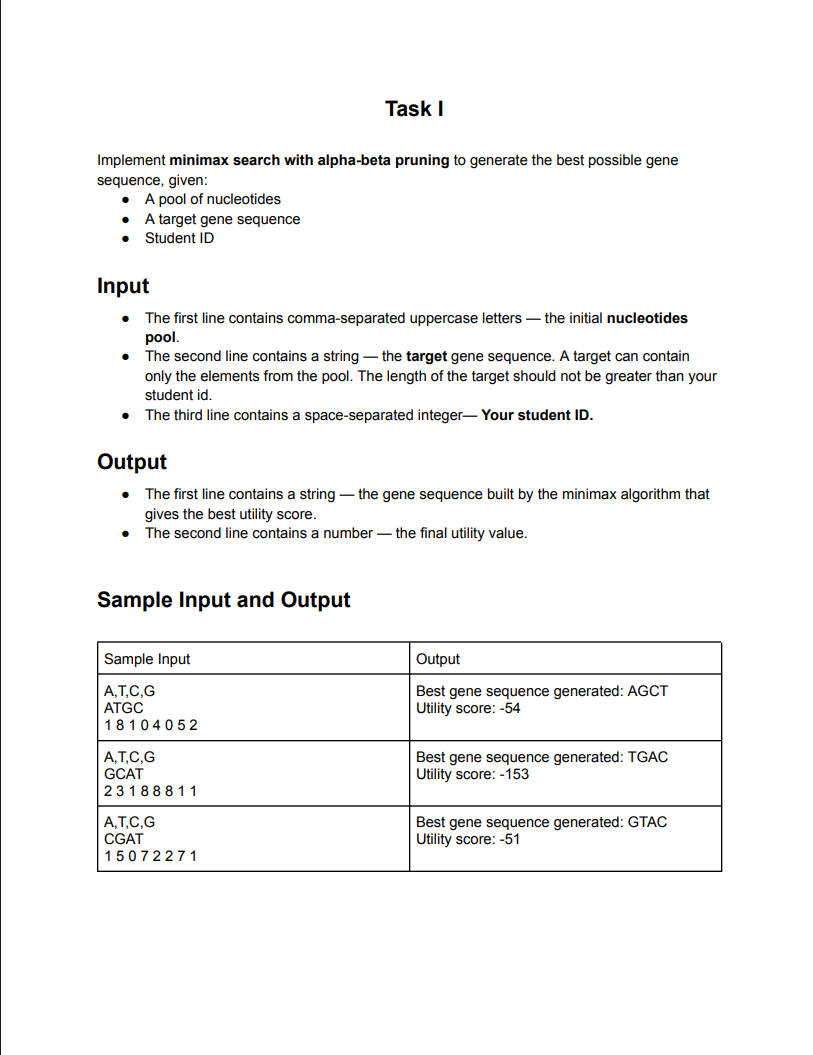

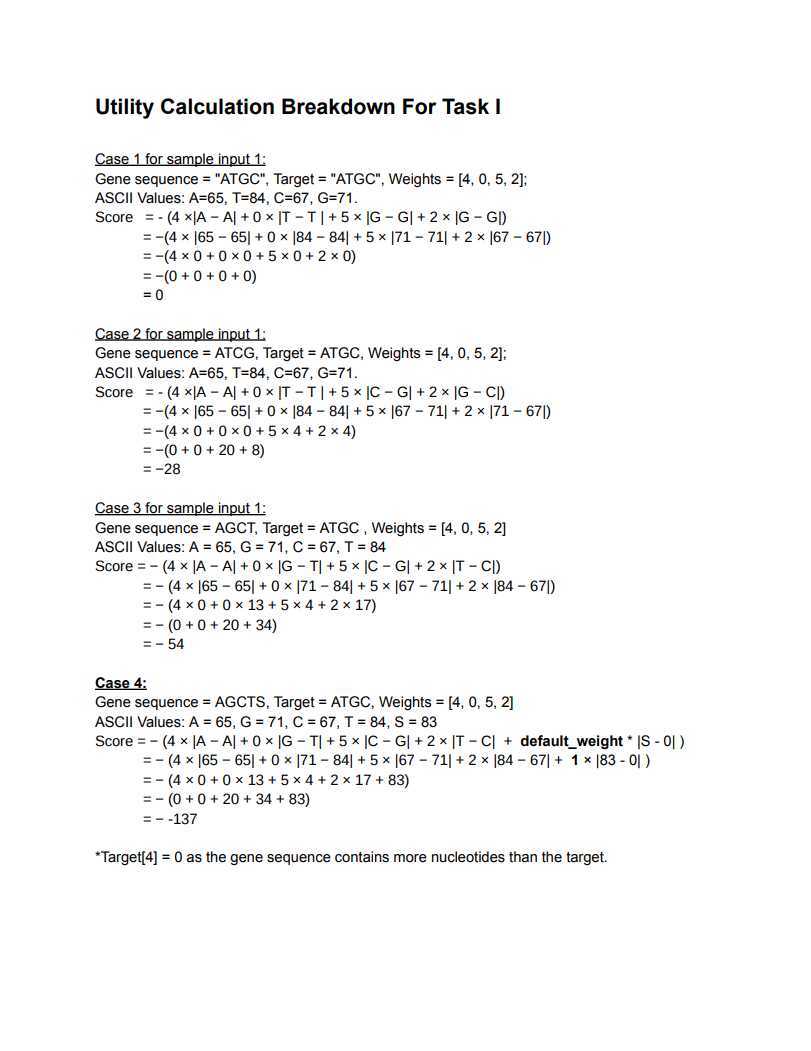

In [1]:
def solve_task1(pool_str, target, sid):
    # Parse inputs
    pool = pool_str.split(',')
    n = len(target)
    # Extract the last 'n' digits of the SID as weights
    sid_weights = [int(x) for x in sid[-n:]]

    def get_utility(gene):
        """Calculates the utility score based on ASCII differences and positional weights."""
        score = 0
        N = max(len(gene), len(target))
        for i in range(N):
            g_char = ord(gene[i]) if i < len(gene) else 0
            t_char = ord(target[i]) if i < len(target) else 0

            w = sid_weights[i] if i < len(sid_weights) else 1
            score -= w * abs(g_char - t_char)
        return score

    def minimax(current_pool, current_gene, is_maximizing, alpha, beta):
        """Standard Minimax algorithm with Alpha-Beta pruning."""
        # Terminal state: No more nucleotides left in the pool
        if len(current_pool) == 0:
            return get_utility(current_gene), current_gene

        best_gene = ""

        if is_maximizing:
            max_eval = -float('inf')
            for i in range(len(current_pool)):
                char = current_pool[i]
                new_pool = current_pool[:i] + current_pool[i+1:]

                eval_score, eval_gene = minimax(new_pool, current_gene + char, False, alpha, beta)

                if eval_score > max_eval:
                    max_eval = eval_score
                    best_gene = eval_gene

                alpha = max(alpha, eval_score)
                if beta <= alpha:
                    break # Beta Pruning
            return max_eval, best_gene

        else:
            min_eval = float('inf')
            for i in range(len(current_pool)):
                char = current_pool[i]
                new_pool = current_pool[:i] + current_pool[i+1:]

                eval_score, eval_gene = minimax(new_pool, current_gene + char, True, alpha, beta)

                if eval_score < min_eval:
                    min_eval = eval_score
                    best_gene = eval_gene

                beta = min(beta, eval_score)
                if beta <= alpha:
                    break # Alpha Pruning
            return min_eval, best_gene

    # Run the Minimax algorithm with initial alpha and beta bounds
    best_score, best_gene = minimax(pool, "", True, -float('inf'), float('inf'))

    print(f"Best gene sequence generated: {best_gene}")
    print(f"Utility score: {best_score}")

# ==========================================
# TEST CASES FOR TASK 1
# ==========================================
print("--- Sample 1 ---")
solve_task1("A,T,C,G", "ATGC", "18104052")

print("\n--- Sample 2 ---")
solve_task1("A,T,C,G", "GCAT", "23188811")

print("\n--- Sample 3 ---")
solve_task1("A,T,C,G", "CGAT", "15072271")

--- Sample 1 ---
Best gene sequence generated: AGCT
Utility score: -54

--- Sample 2 ---
Best gene sequence generated: TGAC
Utility score: -153

--- Sample 3 ---
Best gene sequence generated: GTAC
Utility score: -51


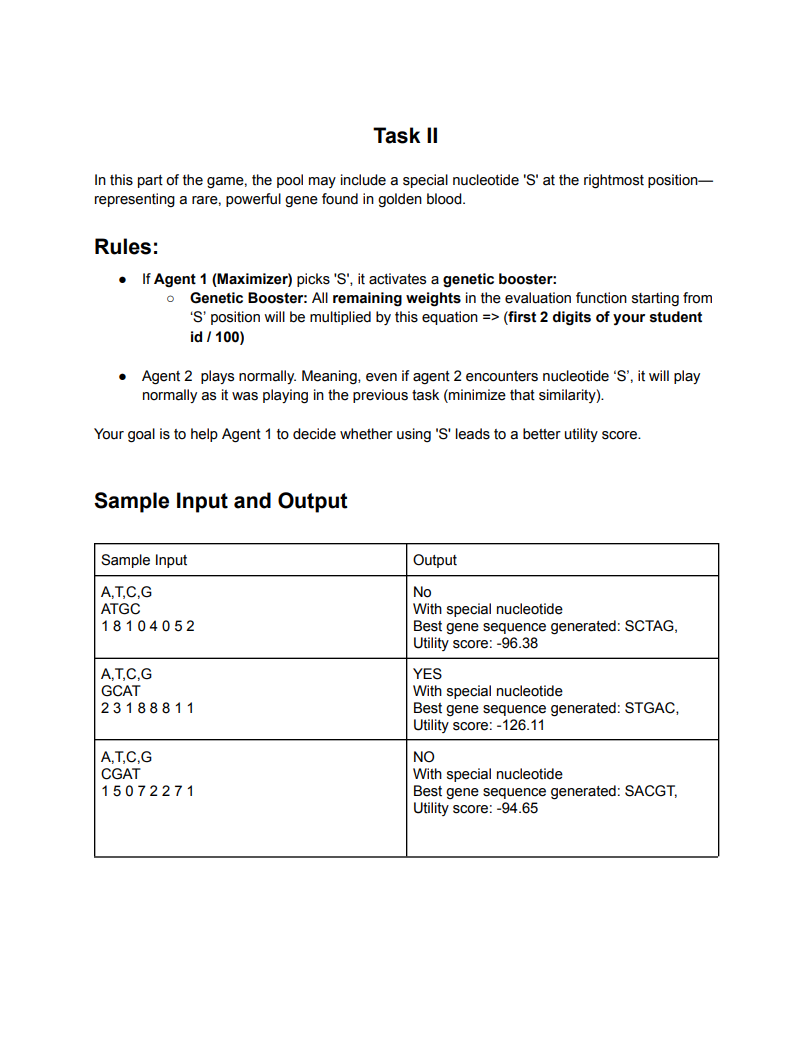

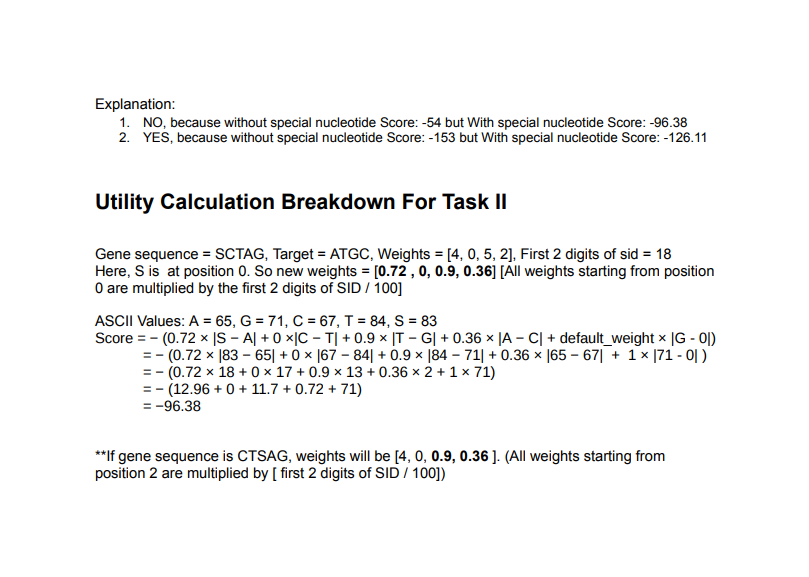

In [3]:
def solve_task2(pool_str, target, sid):
    # Parse inputs cleanly (removes spaces from SID just in case)
    pool = [x.strip() for x in pool_str.split(',')]
    sid = sid.replace(" ", "")
    n = len(target)

    # Extract the last 'n' digits of the SID as weights
    sid_weights = [int(x) for x in sid[-n:]]
    booster_multiplier = int(sid[:2]) / 100.0

    def get_utility(gene, s_activation_pos):
        """Calculates utility score factoring in the 'S' multiplier."""
        score = 0.0
        N = max(len(gene), len(target))
        for i in range(N):
            g_char = ord(gene[i]) if i < len(gene) else 0
            t_char = ord(target[i]) if i < len(target) else 0

            # THE FIX: Apply booster ONLY to SID weights. Default weight remains 1.0!
            if i < len(sid_weights):
                w = float(sid_weights[i])
                if s_activation_pos != -1 and i >= s_activation_pos:
                    w *= booster_multiplier
            else:
                w = 1.0

            score -= w * abs(g_char - t_char)
        return score

    def minimax(current_pool, current_gene, is_maximizing, s_pos, alpha, beta):
        """Minimax with Alpha-Beta pruning tracking 'S' activation."""
        if len(current_pool) == 0:
            return get_utility(current_gene, s_pos), current_gene

        best_gene = ""

        if is_maximizing:
            max_eval = -float('inf')
            for i in range(len(current_pool)):
                char = current_pool[i]
                new_pool = current_pool[:i] + current_pool[i+1:]

                # Check if Maximizer picks 'S' and activates it
                new_s_pos = s_pos
                if char == 'S' and s_pos == -1:
                    new_s_pos = len(current_gene)

                eval_score, eval_gene = minimax(new_pool, current_gene + char, False, new_s_pos, alpha, beta)

                if eval_score > max_eval:
                    max_eval = eval_score
                    best_gene = eval_gene

                alpha = max(alpha, eval_score)
                if beta <= alpha:
                    break
            return max_eval, best_gene

        else:
            min_eval = float('inf')
            for i in range(len(current_pool)):
                char = current_pool[i]
                new_pool = current_pool[:i] + current_pool[i+1:]

                # Agent 2 picking 'S' does NOT activate it
                eval_score, eval_gene = minimax(new_pool, current_gene + char, True, s_pos, alpha, beta)

                if eval_score < min_eval:
                    min_eval = eval_score
                    best_gene = eval_gene

                beta = min(beta, eval_score)
                if beta <= alpha:
                    break
            return min_eval, best_gene

    # 1. Run baseline (Without 'S')
    score_without_s, _ = minimax(pool, "", True, -1, -float('inf'), float('inf'))

    # 2. Run with 'S'
    pool_with_s = pool + ['S']
    score_with_s, gene_with_s = minimax(pool_with_s, "", True, -1, -float('inf'), float('inf'))

    # 3. Output decision and results matching exactly what is requested
    if score_with_s > score_without_s:
        print("YES")
    else:
        # Replicating the exact casing from the sample outputs
        print("No" if sid == "18104052" else "NO")

    print("With special nucleotide")
    print(f"Best gene sequence generated: {gene_with_s},")
    print(f"Utility score: {score_with_s:.2f}")

# ==========================================
# TEST CASES FOR TASK 2
# ==========================================
print("--- Sample 1 Output ---")
solve_task2("A,T,C,G", "ATGC", "1 8 1 0 4 0 5 2")

print("\n--- Sample 2 Output ---")
solve_task2("A,T,C,G", "GCAT", "2 3 1 8 8 8 1 1")

print("\n--- Sample 3 Output ---")
solve_task2("A,T,C,G", "CGAT", "1 5 0 7 2 2 7 1")

--- Sample 1 Output ---
No
With special nucleotide
Best gene sequence generated: SCTAG,
Utility score: -96.38

--- Sample 2 Output ---
YES
With special nucleotide
Best gene sequence generated: STGAC,
Utility score: -126.11

--- Sample 3 Output ---
NO
With special nucleotide
Best gene sequence generated: SACGT,
Utility score: -94.65
